In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [5]:
df = pd.read_csv("student_spending.csv")  # rename if different
df.head()

,Unnamed: 0,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,188,41,78,134,127,72,Credit/Debit Card
1,1,24,Female,Junior,Economics,1006,875,4908,557,365,85,252,74,92,226,129,68,Credit/Debit Card
2,2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,99,130,23,239,112,133,Cash
3,3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,223,99,30,163,105,55,Mobile Payment App
4,4,20,Female,Senior,Computer Science,810,522,3887,825,372,168,194,48,71,88,71,104,Credit/Debit Card


In [6]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                1000 non-null   int64 
 1   age                       1000 non-null   int64 
 2   gender                    1000 non-null   object
 3   year_in_school            1000 non-null   object
 4   major                     1000 non-null   object
 5   monthly_income            1000 non-null   int64 
 6   financial_aid             1000 non-null   int64 
 7   tuition                   1000 non-null   int64 
 8   housing                   1000 non-null   int64 
 9   food                      1000 non-null   int64 
 10  transportation            1000 non-null   int64 
 11  books_supplies            1000 non-null   int64 
 12  entertainment             1000 non-null   int64 
 13  personal_care             1000 non-null   int64 
 14  technology               

In [7]:
label_cols = df.select_dtypes(include=["object"]).columns
encoders = {}

for col in label_cols:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])

df.head()

,Unnamed: 0,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,0,19,2,0,4,958,270,5939,709,296,123,188,41,78,134,127,72,1
1,1,24,0,1,2,1006,875,4908,557,365,85,252,74,92,226,129,68,1
2,2,24,2,1,2,734,928,3051,666,220,137,99,130,23,239,112,133,0
3,3,23,0,2,1,617,265,4935,652,289,114,223,99,30,163,105,55,2
4,4,20,0,2,1,810,522,3887,825,372,168,194,48,71,88,71,104,1


In [9]:
# Calculate total spending as 'Amount'
df['Amount'] = df[['tuition', 'housing', 'food', 'transportation', 'books_supplies', 'entertainment', 'personal_care', 'technology', 'health_wellness', 'miscellaneous']].sum(axis=1)

X = df.drop("Amount", axis=1)
y = df["Amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((800, 18), (200, 18))

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.2f} | Train R²: {train_r2:.4f}")
print(f"Test MSE: {test_mse:.2f} | Test R²: {test_r2:.4f}")

Train MSE: 0.07 | Train R²: 1.0000
Test MSE: 10541.82 | Test R²: 0.9863


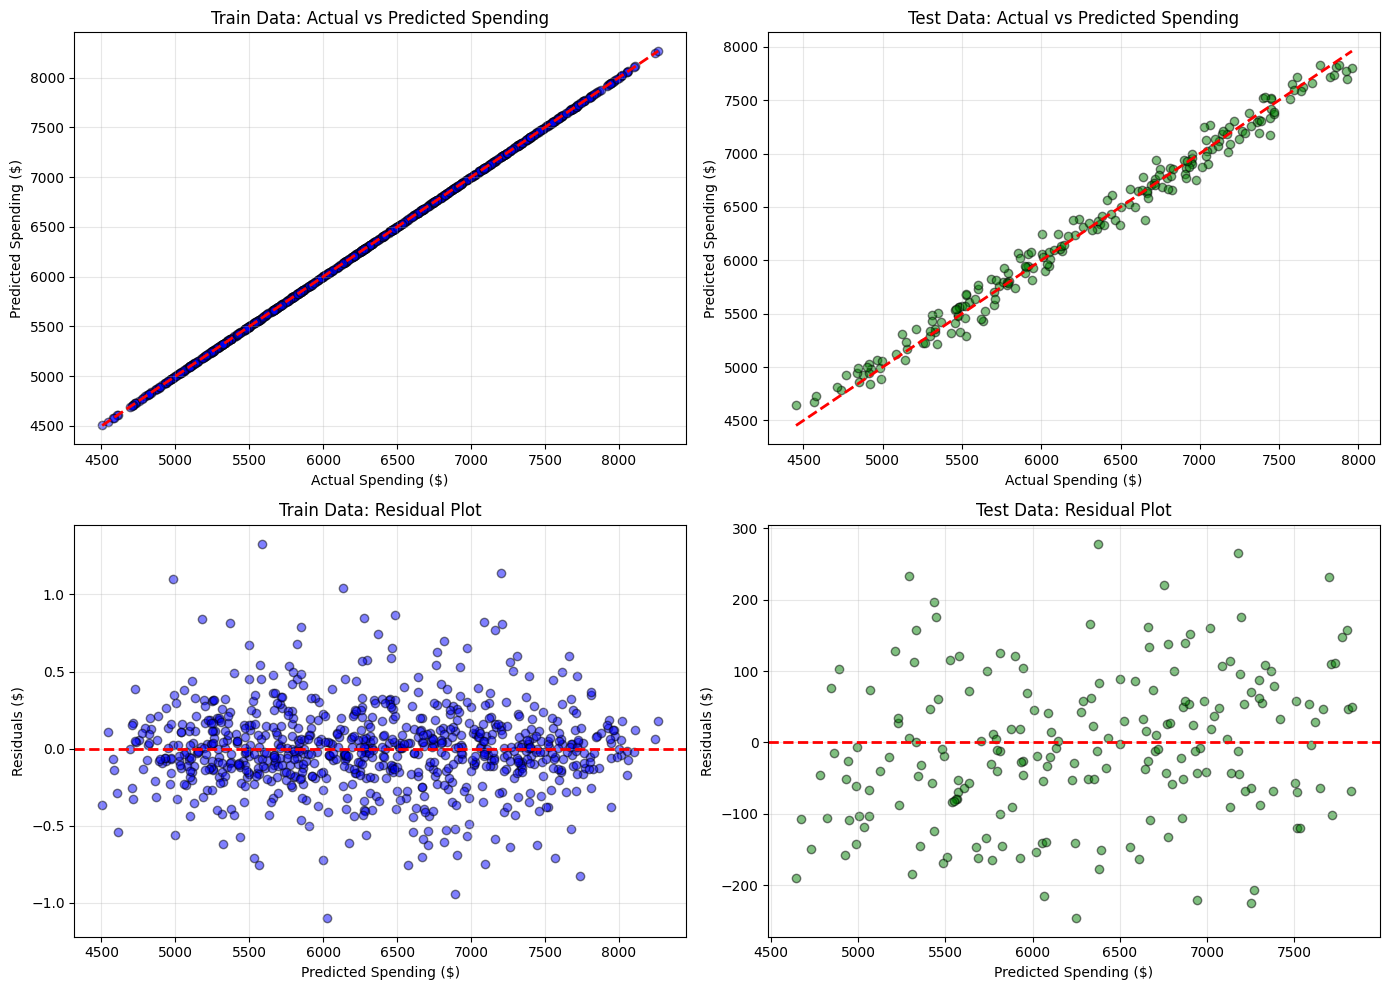

In [16]:
# 1. Actual vs Predicted - Train Data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Train Data - Actual vs Predicted
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, color='blue', edgecolors='k')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Spending ($)')
axes[0, 0].set_ylabel('Predicted Spending ($)')
axes[0, 0].set_title('Train Data: Actual vs Predicted Spending')
axes[0, 0].grid(True, alpha=0.3)

# Test Data - Actual vs Predicted
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5, color='green', edgecolors='k')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Spending ($)')
axes[0, 1].set_ylabel('Predicted Spending ($)')
axes[0, 1].set_title('Test Data: Actual vs Predicted Spending')
axes[0, 1].grid(True, alpha=0.3)

# Residuals - Train Data
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.5, color='blue', edgecolors='k')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Spending ($)')
axes[1, 0].set_ylabel('Residuals ($)')
axes[1, 0].set_title('Train Data: Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# Residuals - Test Data
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.5, color='green', edgecolors='k')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Spending ($)')
axes[1, 1].set_ylabel('Residuals ($)')
axes[1, 1].set_title('Test Data: Residual Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

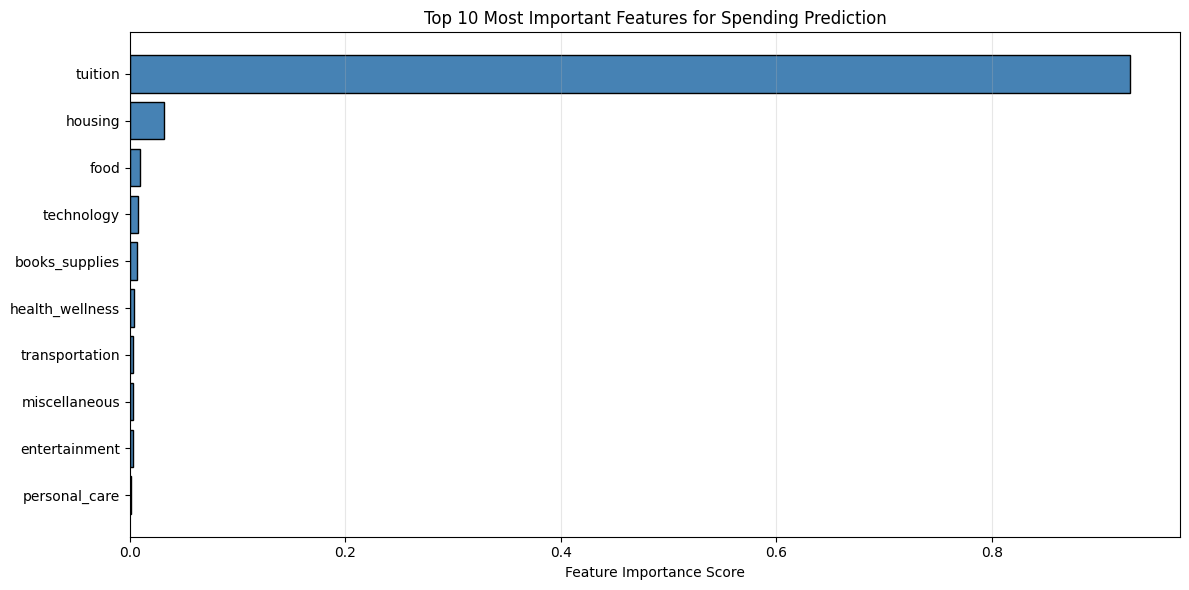

In [17]:
# 2. Feature Importance
feature_importance = model.feature_importances_
feature_names = X.columns

fig, ax = plt.subplots(figsize=(12, 6))
indices = np.argsort(feature_importance)[::-1][:10]  # Top 10 features

ax.barh(range(len(indices)), feature_importance[indices], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(feature_names[indices])
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 10 Most Important Features for Spending Prediction')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

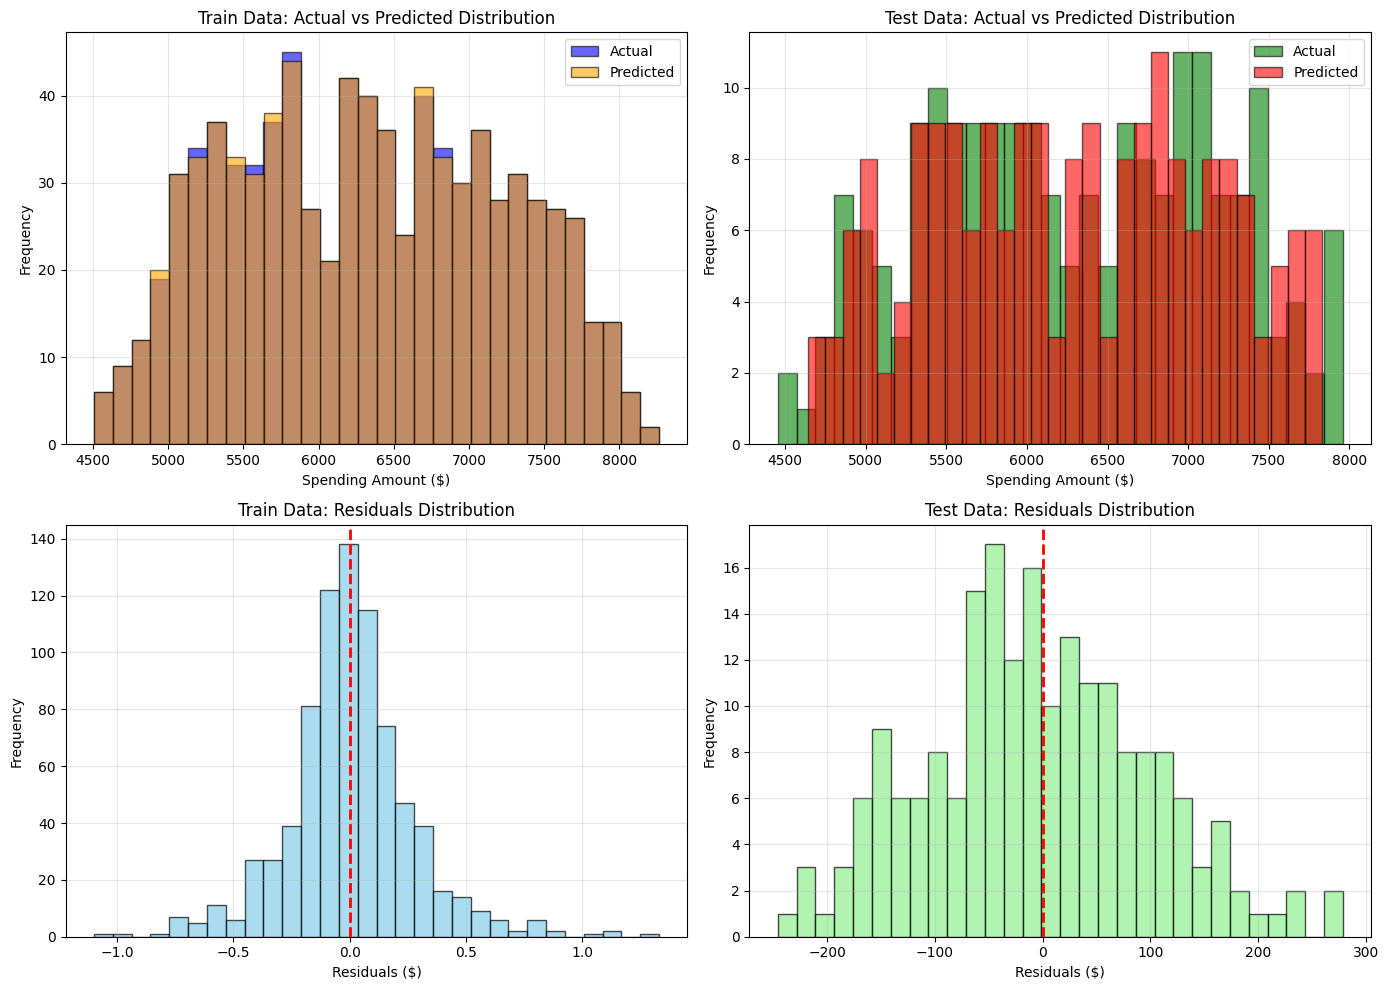

In [18]:
# 3. Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Train Predictions Distribution
axes[0, 0].hist(y_train, bins=30, alpha=0.6, label='Actual', color='blue', edgecolor='black')
axes[0, 0].hist(y_train_pred, bins=30, alpha=0.6, label='Predicted', color='orange', edgecolor='black')
axes[0, 0].set_xlabel('Spending Amount ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Train Data: Actual vs Predicted Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test Predictions Distribution
axes[0, 1].hist(y_test, bins=30, alpha=0.6, label='Actual', color='green', edgecolor='black')
axes[0, 1].hist(y_test_pred, bins=30, alpha=0.6, label='Predicted', color='red', edgecolor='black')
axes[0, 1].set_xlabel('Spending Amount ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Test Data: Actual vs Predicted Distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Train Residuals Distribution
axes[1, 0].hist(train_residuals, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Train Data: Residuals Distribution')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].grid(True, alpha=0.3)

# Test Residuals Distribution
axes[1, 1].hist(test_residuals, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Residuals ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Test Data: Residuals Distribution')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

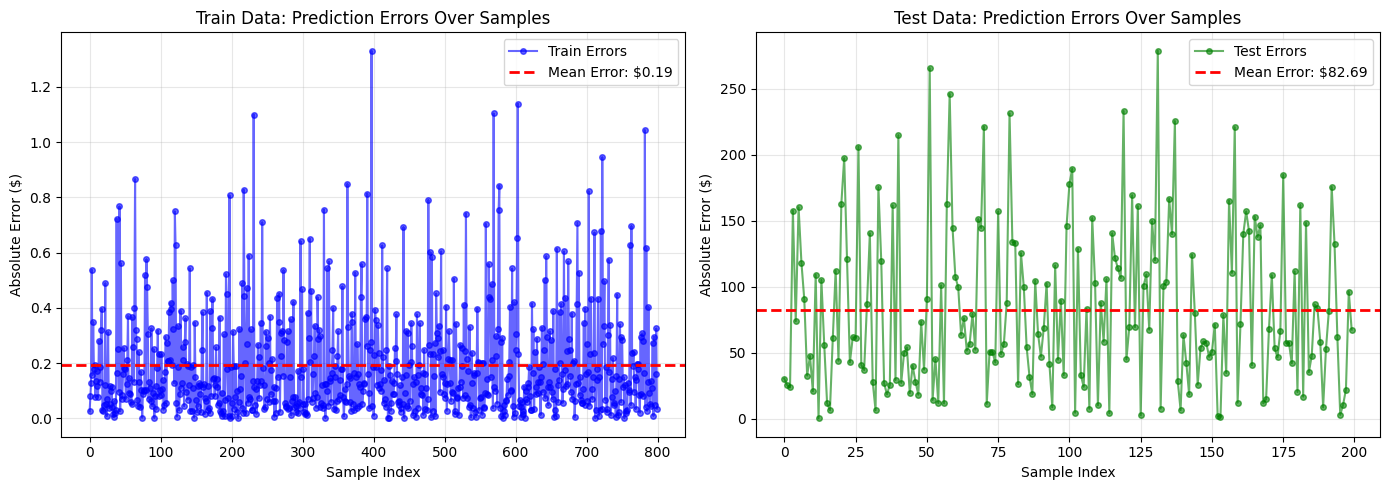

In [19]:
# 4. Error Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train Error
train_errors = np.abs(train_residuals)
axes[0].plot(train_errors.values, 'o-', color='blue', alpha=0.6, label='Train Errors', markersize=4)
axes[0].axhline(y=train_errors.mean(), color='r', linestyle='--', lw=2, label=f'Mean Error: ${train_errors.mean():.2f}')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Absolute Error ($)')
axes[0].set_title('Train Data: Prediction Errors Over Samples')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test Error
test_errors = np.abs(test_residuals)
axes[1].plot(test_errors.values, 'o-', color='green', alpha=0.6, label='Test Errors', markersize=4)
axes[1].axhline(y=test_errors.mean(), color='r', linestyle='--', lw=2, label=f'Mean Error: ${test_errors.mean():.2f}')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Absolute Error ($)')
axes[1].set_title('Test Data: Prediction Errors Over Samples')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:


def predict_student_spending(user_data, encoders, scaler, model):
    """
    Takes raw user input, preprocesses it, and returns the predicted spending amount.
    """
    # 1. Convert the user's dictionary into a Pandas DataFrame
    df_new = pd.DataFrame([user_data])
    
    # 2. Encode the categorical columns using the fitted encoders from training
    label_cols = ["gender", "year_in_school", "major", "preferred_payment_method"]
    for col in label_cols:
        # Use .transform() to apply the exact same mapping used on training data
        df_new[col] = encoders[col].transform(df_new[col])
        
    # 3. Ensure the columns are in the exact same order as your training features (X)
    # Note: "Unnamed: 0" wasn't dropped in your original code, so it's required as a feature.
    expected_cols = [
        "Unnamed: 0", "age", "gender", "year_in_school", "major", 
        "monthly_income", "financial_aid", "tuition", "housing", "food", 
        "transportation", "books_supplies", "entertainment", "personal_care", 
        "technology", "health_wellness", "miscellaneous", "preferred_payment_method"
    ]
    df_new = df_new[expected_cols]
    
    # 4. Scale the features using your fitted StandardScaler
    X_new_scaled = scaler.transform(df_new)
    
    # 5. Predict the total spending amount
    prediction = model.predict(X_new_scaled)
    
    return prediction[0]


# ==========================================
# Example Usage
# ==========================================

# A sample dictionary representing new data a user might enter
new_student_data = {
    "Unnamed: 0": 1005,  # Dummy CSV index
    "age": 21,
    "gender": "Female",
    "year_in_school": "Junior",
    "major": "Computer Science",
    "monthly_income": 1000,
    "financial_aid": 500,
    "tuition": 3500,
    "housing": 800,
    "food": 350,
    "transportation": 100,
    "books_supplies": 200,
    "entertainment": 150,
    "personal_care": 50,
    "technology": 100,
    "health_wellness": 80,
    "miscellaneous": 70,
    "preferred_payment_method": "Credit/Debit Card"
}

# Make sure you run this in the same notebook/environment where your 
# `encoders` dictionary, `scaler`, and `model` are already stored in memory!
predicted_amount = predict_student_spending(new_student_data, encoders, scaler, model)

print(f"Predicted Total Spending: ${predicted_amount:.2f}")

Predicted Total Spending: $5391.21
